[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lnccbrown/Carney_ARIA_Workshop_2026/blob/main/03_advanced_topics.ipynb) &nbsp; **Notebook 3/3 — Advanced topics** — Carney ARIA Workshop 2026


In [1]:
# Setup — safe to run anywhere; does nothing once everything is in place.
# On Google Colab this installs hssm v0.4.1 and fetches the files this
# notebook needs. Locally (cloned repo + uv environment) it is a no-op.
import importlib.util
import subprocess
import sys

IN_COLAB = importlib.util.find_spec("google.colab") is not None

if IN_COLAB and importlib.util.find_spec("hssm") is None:
    print("Colab detected — installing hssm (takes a minute or two)...")
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "hssm==0.4.0", "zeus-mcmc"],
        check=True,
    )


# HSSM: Advanced topics


<div style="text-align: center;">
  <img src="images/HSSM_logo.png" alt="HSSM logo" style="height: 120px; width: auto; max-width: 80%;">
</div>

> **Carney/ARIA workshop 2026 — notebook 3 of 3.** Three advanced topics, each recomposed
> from an existing tutorial:
>
> 1. **Custom PyMC models with HSSM random variables** — from the
>    [PyMC tutorial](https://lnccbrown.github.io/HSSM/tutorials/pymc/) and the
>    [MathPsych 2025 workshop](https://lnccbrown.github.io/HSSM/tutorials/pymc_to_hssm/):
>    first with distributions HSSM already ships, then constructing a new
>    random variable from an ONNX likelihood network.
> 2. **Compiling the likelihood and sampling with `zeus`** — from the
>    [compiled log-likelihood tutorial](https://lnccbrown.github.io/HSSM/tutorials/compile_logp/).
> 3. **Per-parameter centered/non-centered parameterization** — from the
>    [parameterization tutorial](https://github.com/lnccbrown/HSSM/blob/main/docs/tutorials/parameterization_per_parameter.ipynb)
>    (requires hssm >= 0.4.1).

# 1. Using the low-level API from HSSM directly with PyMC

This is a tutorial for advanced users who prefer to use the convenience functions and classes in HSSM to create models and sample in PyMC without using `bambi`. We assume that the readers of this tutorial are familiar with the internals of `PyMC`, `pytensor`, and/or `JAX`.

In addition to the high-level API that relies on `bambi` for model creation, HSSM also features a low-level API that it internally calls for creating `pytensor` `Op`s and `pm.Distribution`s. Experienced users can use the low-level API directly with `PyMC` to create even more customized models. This tutorial shows how advanced users can utilize the low-level API and convenience functions that HSSM provides to interface with PyMC.

## Load Modules

In [2]:
import arviz as az
import pymc as pm
from matplotlib import pyplot as plt
import hssm

## Build a model directly from PyMC

The `DDM` is directly available as a `pm.Distribution`s, we can create models directly with PyMC. We first simulate some data using `ssm_simulators` and then use `PyMC` to specify the model and sample from the it.

In [3]:
# Simulate some data
v_true, a_true, z_true, t_true = [0.5, 1.5, 0.5, 0.5]
dataset = hssm.simulate_data(
    model="ddm",
    theta=[v_true, a_true, z_true, t_true],
    size=1000,
)

dataset

,rt,response
0,2.881866,1.0
1,1.133892,1.0
2,2.402993,-1.0
3,1.929978,1.0
4,2.071124,-1.0
...,...,...
995,1.458236,-1.0
996,3.261452,1.0
997,1.297753,-1.0
998,1.054990,1.0


In [4]:
# This is a pm.Distribution available in HSSM
# There is also a DDM_SDV class for DDMs with the sv parameter
from hssm.likelihoods import DDM

with pm.Model() as ddm_pymc:
    # Prior
    v = pm.Uniform("v", lower=-10.0, upper=10.0)
    a = pm.Uniform("a", lower=0.5, upper=2.5)
    z = pm.Uniform("z", lower=0.01, upper=0.99)
    t = pm.Uniform("t", lower=0.0, upper=0.6, initval=0.1)
    
    # Likelihood
    ddm = DDM("ddm", v=v, a=a, z=z, t=t, observed=dataset.values)

    # Sample
    ddm_pymc_trace = pm.sample(mp_ctx="spawn", tune=200, draws=200)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t]


Output()

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 7 seconds.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


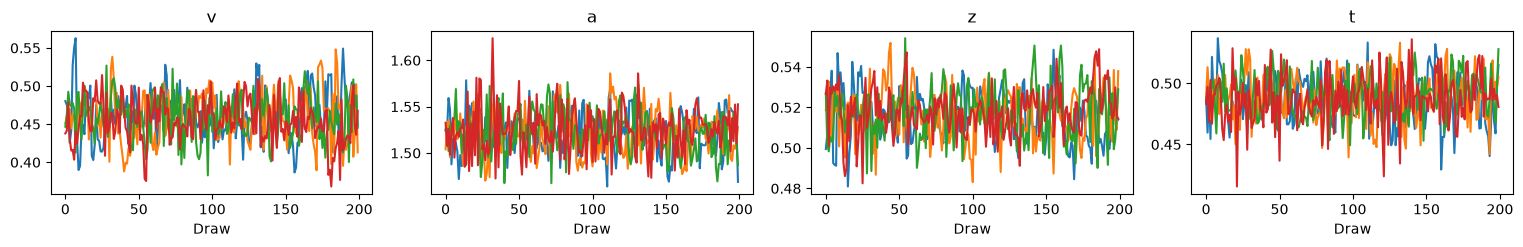

In [5]:
az.plot_trace(ddm_pymc_trace)
plt.tight_layout()

## Building top-level distributions with `make_distribution_for_supported_model`

**Note**: this feature was added in HSSM 0.2.12.

HSSM supports building a `pm.Distribution` class for any supported model with the `make_distribution_for_supported_model` convenience function. All you need is a string specifying which model you would like and the kind of likelihood.

In [6]:
from hssm.distribution_utils import make_distribution_for_supported_model

ANGLE = make_distribution_for_supported_model(
    "angle", loglik_kind="approx_differentiable"
)

with pm.Model() as angle_pymc:
    # Priors
    v = pm.TruncatedNormal("v", mu=0.0, sigma=1.0, lower=-2.5, upper=2.5)
    a = pm.HalfNormal("a", sigma=2.0)
    z = pm.Uniform("z", lower=0.1, upper=0.9)
    t = pm.Uniform("t", lower=0.0, upper=0.6, initval=0.1)
    theta = pm.Uniform("theta", lower=0, upper=1.0)

    # Likelihood
    angle = ANGLE(
        "angle",
        v=v,
        a=a,
        z=z,
        t=t,
        theta=theta,
        observed=dataset.values,
    )

    # Sample
    angle_pymc_trace = pm.sample(mp_ctx="spawn", tune=200, draws=200)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t, theta]


Output()

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 20 seconds.


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


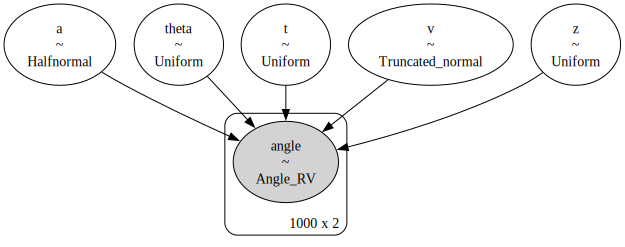

In [7]:
pm.model_to_graphviz(angle_pymc)

In [8]:
az.summary(angle_pymc_trace )

,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
v,0.452,0.029,0.41,0.5,424,427,1.01,0.0014,0.00089
a,1.519,0.033,1.5,1.6,300,492,1.01,0.0019,0.0013
z,0.52,0.0124,0.5,0.54,467,545,1.00,0.00057,0.00041
t,0.495,0.023,0.46,0.53,383,389,1.00,0.0012,0.00078
theta,0.013,0.01,0.0017,0.03,161,145,1.01,0.00066,0.00051


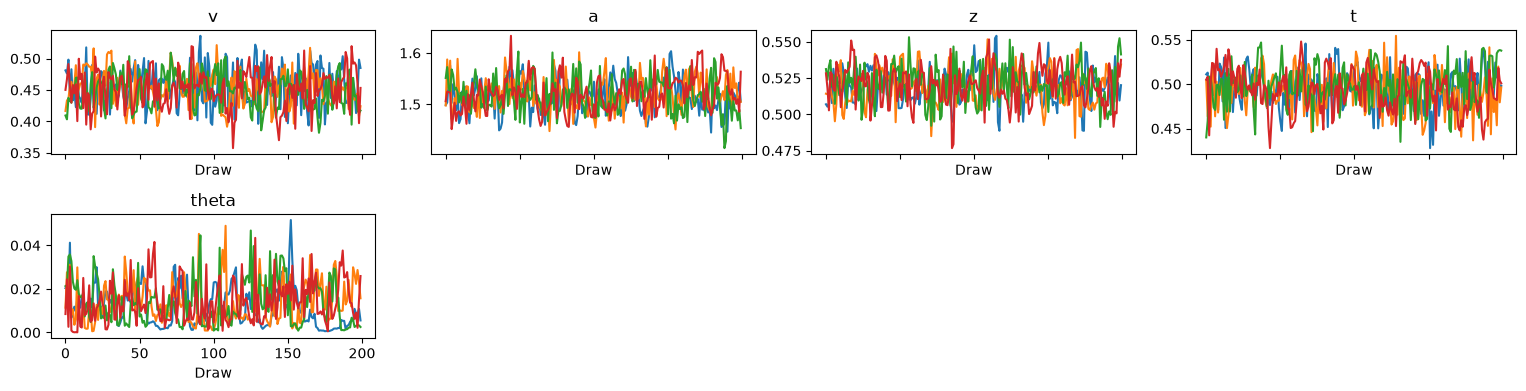

In [9]:
az.plot_trace(angle_pymc_trace)
plt.tight_layout()

# 2. Compiling the likelihood and sampling with `zeus`

HSSM models expose their log-likelihood as a compiled function, which makes it
easy to hand the model to samplers outside the PyMC ecosystem. This section is
the compiled log-likelihood tutorial, run on a simple DDM; the same recipe
works for the Race-3 model above (see the MathPsych tutorial for that
variant).

In [10]:
import matplotlib.pyplot as plt
import numpy as np
import hssm

## Extracting the likelihood

### Simulate Data

In [11]:
obs_ddm = hssm.simulate_data(
    theta={"v": 0.5, "a": 1.5, "t": 0.3, "z": 0.5},
    model="angle",
    size=500,
)

### Basic HSSM model

In [12]:
model = hssm.HSSM(
    data=obs_ddm, loglik_kind="analytical", process_initvals=True, p_outlier=0
)

Model initialized successfully.


### Compile the log-likelihood

We can now use the `compile_logp()` method to compile the log-likelihood function created by the `hssm`. This illustrates the simplest use case, `compile_logp()` with no additional arguments. 
Check the documentation for more details on how to make `compile_logp()` work for more customized use cases.

In [13]:
logp_fun = model.compile_logp()  # msynth.pymc_model.compile_logp()
print(logp_fun(model.initial_point(transformed=False)))

-33054.449962780134


Note that `logp_fun` takes as input a dictionary of parameter values with keys corresponding to the parameters names
created by `hssm`. It might be helpful to take a look at the `initial_point()` method to see how the parameters are passed.

In [14]:
print(model.initial_point(transformed=False))

{'a': array(2.), 't': array(2.), 'z': array(0.5), 'v': array(0.)}


### Timing the compiled log-likelihood

In [15]:
# time
import time

my_start_point = model.initial_point(transformed=False)
start_time = time.time()
for i in range(1000):
    logp_fun(my_start_point)
print((time.time() - start_time) / 1000)

7.614493370056152e-05


## Using the compiled log-likelihood function

For illustration, we use our compile log-likelihood function with a different MCMC sampler, using the 
[`zeus`](https://github.com/minaskar/zeus) package.

> **Note:** `zeus` is an optional dependency of `hssm` and can be installed using the command `pip install hssm[notebook]`. Alternatively, you can install it directly with `pip install zeus-mcmc`.

### Wrap the compiled log-likelihood to accomodate `zeus`

In [16]:
def mylogp(theta: list[float]) -> float:
    """Wrap function for compiled log probability function to work with zeus sampler.

    Args
    ----
        theta: List of model parameters [v, a, z, t] where:
            v: Drift rate
            a: Boundary separation
            z: Starting point
            t: Non-decision time

    Returns
    -------
        float: Log probability value for the given parameters
    """
    v, a, z, t = theta
    return logp_fun({"v": v, "a": a, "z": z, "t": t})

### Test sampling with `zeus`


In [17]:
import zeus

start = np.random.uniform(low=-0.2, high=0.2, size=(8, 4)) \
    + np.tile(
    [0.5, 1.5, 0.5, 0.3], (8, 1)
)
sampler = zeus.EnsembleSampler(8, 4, mylogp)

In [18]:
sampler.run_mcmc(start, 1000)

Initialising ensemble of 8 walkers...


Sampling progress :   0%|          | 0/1000 [00:00<?, ?it/s]

Sampling progress :   2%|▏         | 21/1000 [00:00<00:04, 198.29it/s]

Sampling progress :   4%|▍         | 41/1000 [00:00<00:05, 184.01it/s]

Sampling progress :   6%|▌         | 60/1000 [00:00<00:05, 178.75it/s]

...

Sampling progress :  91%|█████████ | 912/1000 [00:04<00:00, 217.44it/s]

Sampling progress :  94%|█████████▎| 936/1000 [00:04<00:00, 221.04it/s]

Sampling progress :  96%|█████████▌| 960/1000 [00:04<00:00, 223.18it/s]

Sampling progress :  98%|█████████▊| 983/1000 [00:04<00:00, 212.85it/s]

Sampling progress : 100%|██████████| 1000/1000 [00:04<00:00, 206.25it/s]

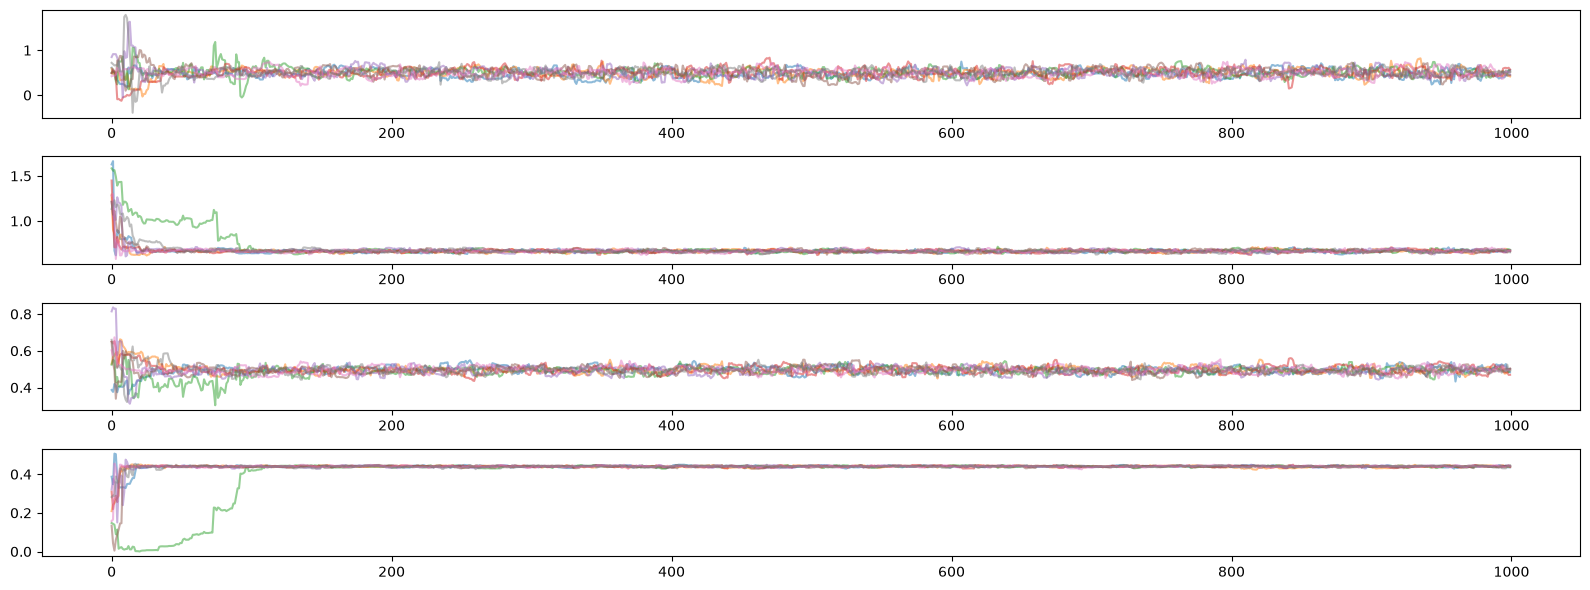

In [19]:
plt.figure(figsize=(16, 1.5 * 4))
for n in range(4):
    plt.subplot2grid((4, 1), (n, 0))
    plt.plot(sampler.get_chain()[:, :, n], alpha=0.5)
plt.tight_layout()
plt.show()

# 3. (OPTIONAL) Advanced Custom Distribution Construction
### Building custom top-level distributions with `make_distribution`

**Note**: This tutorial has undergone major updates in HSSM 0.2.1+ following breaking changes in the `distribution_utils` api. Please follow this tutorial closely if your previous code no longer works.

### `make_distribution`

The above example shows that, as long as the top-level distribution is known, modeling can be done in `PyMC` as well without using `Bambi`. However, as [this official `PyMC` tutorial](https://www.pymc.io/projects/docs/en/latest/contributing/implementing_distribution.html) shows, creating a distribution in PyMC can be a time consuming-task. You will need to create a `RandomVariable` first and then define your custom `Distribution` by extending `pm.Distribution` class. From `PyMC 5.0.0` on, `pm.CustomDist` simplifies this process, but the use case is not applicable to complex likelihoods in HSSM. Therefore, HSSM provides convenience functions in its `distribution_utils` submodule that make this process easy. Next, we use another example to show how we can use these functions to create custom `pm.Distribution`s to be used with `PyMC`.

**Use Case**: Suppose we have a likelihood function for DDM models with standard deviations for `v` written. This model has 5 parameters: `v, a, z, t, sv`, and we want to use this function as the likelihood to create a `pm.Distribution` for modeling with `PyMC`. We can use `make_distribution` for this purpose.

**Note**: 
This distribution is already available in HSSM at `hssm.likelihoods.DDM_SDV`. For illustration purposes, we go through the same process in which this distribution is created. We can use the same procedure for other distributions not currently available in HSSM.

Initializing NUTS using jitter+adapt_diag...


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [v, a, z, t, sv]


...

Sampling 4 chains for 200 tune and 200 draw iterations (800 + 800 draws total) took 10 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


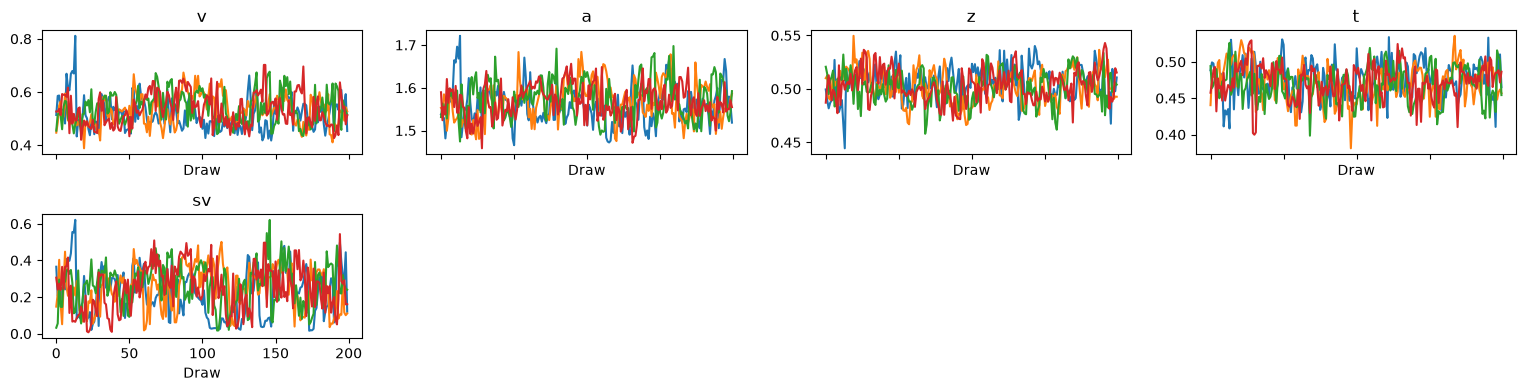

In [20]:
# This is a likelihood function for the DDM with SDV
# Different from DDM which we imported in the previous example,
# which is a pm.Distribution
from hssm.distribution_utils import make_distribution
from hssm.likelihoods import logp_ddm_sdv

# We use `make_distribution` to wrap the likelihood function into a pm.Distribution
DDM_SDV = make_distribution(
    rv="ddm_sdv",
    loglik=logp_ddm_sdv,
    list_params=["v", "a", "z", "t", "sv"],
    bounds={"t": (0, 1)},
)

with pm.Model() as ddm_sdv_model:
    v = pm.Uniform("v", lower=-10.0, upper=10.0)
    a = pm.HalfNormal("a", sigma=2.0)
    z = pm.Uniform("z", lower=0.01, upper=0.99)
    t = pm.Uniform("t", lower=0.0, upper=0.6, initval=0.1)
    sv = pm.HalfNormal("sv", sigma=2.0)

    ddm = DDM_SDV("ddm", v=v, a=a, z=z, t=t, sv=sv, observed=dataset.values)

    ddm_sdv_trace = pm.sample(mp_ctx="spawn", tune=200, draws=200)

az.plot_trace(ddm_sdv_trace)
plt.tight_layout()

The above example shows how to use the `make_distribution` factory function to create a `pm.Distribution` class that can be used for modeling in `PyMC` in the code above. All you need is a likelihood function that can be directly used with `pytensor`. This mostly is a Python function written in `pytensor`, as is the case with `logp_ddm_sdv`. If you have a likelihood function written with JAX or Cython, or if you have an approximate differentiable likelihood saved in an `onnx` file, you need to wrap this likelihood in a pytensor `Op` before using the `make_distribution` function. The next section describes how to do so. Please refer to the next section to create a `pytensor`-compatible likelihood function before coming back to this section to create a `PyMC` `Distribution` class.

Detailed usage of the `make_distribution` factory function is as follows:

- `rv`: a `str` or a `RandomVariable`. If a `str` is provided, a `RandomVariable` class will be created automatically. This `RandomVariable` will use the `str` to identify a simulator provided in the `ssm_simulators` package as its `rng_fn` (sampling) function. If this `str` is not one of the entries to the `model_config` `dict` specified [here](https://github.com/lnccbrown/ssm-simulators/tree/main/ssms/config), then the `Distribution` will still be created but with a warning that any attempt to sample from the `RandomVariable` will result in an Error. That includes sampling from the posterior distribution. The user could create his/her own `RandomVariable` class and define its `rng_fn` class method for sampling.

- `loglik`: an instance of a `pytensor` `Op` object or a Python `Callable`. This is where the likelihood function is passed in. `make_distribution` assumes that the likelihood function is directly usable as part of a `pytensor` graph, such as a function written in `pytensor` or an instance of a `pytensor` `Op` object. Otherwise, please refer to the next section to create a `pytensor`-compatible likelihood function.

  The signature for the likelihood also has to follow a specific pattern. Please refer to [this section](likelihoods.ipynb#using-custom-likelihoods) for more details.

- `list_params`: a list of `str`s specifying the parameters used in the model. **Note** the order in which the parameters are defined in this list is __very__ important! In principle it has to be consistent with the order in which parameters are passed to the `Op` or `Callable` specified with `loglik`.

- `bounds`: a `dict` of `param : (lower, upper)` specifying the range of values that each parameter can take. HSSM currently does not support specifying `inf` or `-inf` as bounds but will in an update in the near future.

Once the distribution is created, you can use it with `PyMC` just as the `DDM` class created above.

### Creating `pytensor`-compatible likelihood functions with `make_likelihood_callable`

**Update notice**: Up until HSSM 0.2.0, there used to be a `make_distribution_from_onnx` function for creating `pm.Distribution`s directly from `onnx` files. That function is now deprecated in favor of a more general and customizable process described below.

Sometimes users might have written a custom likelihood in `JAX`, `Cython`, or `numba` that they would like to incorporate into their `PyMC` modeling workflows. They might also want to incorporate a neural network as an approximate likelihood function. In all of these cases, they can use `make_likelihood_callable` to wrap these non-`pytensor`-compatible likelihoods into a `pytensor` `Op`, so that it can be used in the sampling process. We now describe both of these use cases:

1. I have a function written in `JAX`, `Cython`, `numba`, or even pure Python:

In this case, we assume that these are "black box" likelihoods that are not differentiable. We do know that JAX functions are differentiable, and we are planning to support differentiable `JAX` likelihoods soon, but for now, we assume that if this function is written in `JAX`, it is a `jit`ted `JAX` function that is not differentiable.

```python
from hssm.distribution_utils import make_likelihood_callable

# Suppose you have a non-differentiable function called my_awesome_likelihood_func
loglik_op = make_likelihood_callable(
    loglik=my_awesome_likelihood_func,
    loglik_kind="blackbox",
)

MY_DIST = make_distribution(
    loglik=loglik_op,
    ...
)
```

What happens under the hood is that `make_likelihood_callable` will construct an `Op` and wrap this `Op` around the function. Please note that this does **NOT** make the function differentiable. When using the `MY_DIST` distribution created above, please use a sampler that does not make use of the gradients such as the slice sampler.

2. I have a neural network saved in an `onnx` file that I want to use as the likelihood function.

This use case is very similar to the one above. All you need to do is to provide a `str` or a `Path` to the onnx file. `make_likelihood_callable` will look for the file locally first. If the file is not available locally, it will also check the [HSSM hugging face model repository](https://huggingface.co/franklab/HSSM/tree/main) to look for the model.

HSSM will translate the `onnx` file either into a `JAX` function or a `pytensor` function, depending on which `backend` you specify. When the `jax` backend is chosen, please also provide a list of `bool`s to `param_is_reg` indicating which of the parameters will be the target of a regression. This tells JAX how to vectorize the comptuation for maximum performance.

HTTP Request: HEAD https://huggingface.co/franklab/HSSM/resolve/main/ddm.onnx "HTTP/1.1 302 Found"


Start tracing the jax_func model to get some static info


Initializing NUTS using jitter+adapt_diag...


Initializing NUTS using jitter+adapt_diag...


/Users/afengler/Projects/proj_carney_workshop_2026/Carney_ARIA_Workshop_2026/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run LANLogpOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(
/Users/afengler/Projects/proj_carney_workshop_2026/Carney_ARIA_Workshop_2026/.venv/lib/python3.14/site-packages/pytensor/link/numba/dispatch/basic.py:234: UserWarning: Numba will use object mode to run LANLogpVJPOp's perform method. Set `pytensor.config.compiler_verbose = True` to see more details.
  warnings.warn(


...

Sampling 4 chains for 500 tune and 200 draw iterations (2_000 + 800 draws total) took 24 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


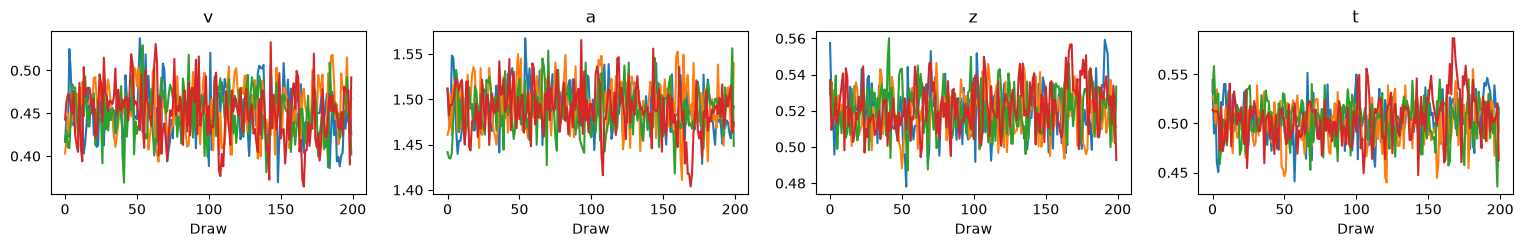

In [21]:
from hssm.distribution_utils import (
    make_distribution,
    make_likelihood_callable,
)

loglik_op = make_likelihood_callable(
    loglik="ddm.onnx",  # will be downloaded from huggingface
    loglik_kind="approx_differentiable",
    backend="jax",  # the onnx will be translated to JAX
    params_is_reg=[False] * 4,  # required if backend is JAX.
    # Since the model below has no regression, we provide a list of 4 `False`s
)

DDM_JAX = make_distribution(
    rv="ddm",
    loglik=loglik_op,
    list_params=["v", "a", "z", "t"],
    bounds={"t": (0, 2), "a": (0, 2.5)},
)

with pm.Model() as ddm_jax_model:
    v = pm.Uniform("v", lower=-3, upper=3)
    a = pm.Gamma("a", mu=0.5, sigma=1.0)
    z = pm.Uniform("z", lower=0.1, upper=0.9)
    t = pm.Uniform("t", lower=0.01, upper=1.0, initval=0.1)

    ddm = DDM_JAX("ddm", v=v, a=a, z=z, t=t, observed=dataset.values)

    ddm_jax_trace = pm.sample(mp_ctx="spawn", tune=500, draws=200)

az.plot_trace(ddm_jax_trace)
plt.tight_layout()

The distributions above already existed inside HSSM. The next section — from
the MathPsych 2025 workshop tutorial — builds a **new** random variable from
scratch: a 3-accumulator race model, whose likelihood comes as an ONNX
network, wired into a raw `pm.Model` via `make_likelihood_callable` and
`make_distribution`.

# 4. (OPTIONAL) Per-parameter centered vs. non-centered parameterization

Sampling geometry matters as much as model specification. Since hssm 0.4.1 you
can choose the parameterization *per parameter*. This section is the
parameterization tutorial in full.

### Setup

In [22]:
import logging
import warnings

warnings.simplefilter("ignore")
logging.getLogger("hssm").setLevel(logging.ERROR)  # quiet info/warnings for the demo

import bambi as bmb

import hssm
from hssm import Prior

hssm.set_floatX("float32")
print("hssm", hssm.__version__, "| bambi", bmb.__version__)

hssm 0.4.0 | bambi 0.19.0


In [23]:
data = hssm.load_data("cavanagh_theta")
data.head()

,participant_id,stim,rt,response,theta,dbs,conf
0,0,LL,1.21,1.0,0.656275,1,HC
1,0,WL,1.63,1.0,-0.327889,1,LC
2,0,WW,1.03,1.0,-0.480285,1,HC
3,0,WL,2.77,1.0,1.927427,1,LC
4,0,WW,1.14,-1.0,-0.213236,1,HC


We will detect the parameterization **structurally**, without sampling: bambi
creates a standard-normal `<param>_..._offset` random variable for each
*non-centered* group term (and a `Deterministic` equal to `offset * sigma`). A
*centered* term instead has a direct `<param>_<group>` random variable. So the
set of parameters that own an `*_offset` free RV is exactly the set of
non-centered parameters.

In [24]:
def noncentered_params(model):
    """Return HSSM parameters whose group term uses the non-centered form."""
    names = [rv.name for rv in model.pymc_model.free_RVs]
    return sorted({n.split("_")[0] for n in names if "_offset" in n})

### A hierarchical model — the default

We give both `v` (drift rate) and `a` (boundary separation) a by-participant
random intercept. bambi's default is **non-centered everywhere**, so both
parameters get an `*_offset`.

In [25]:
hierarchical = [
    {"name": "v", "formula": "v ~ 1 + (1|participant_id)"},
    {"name": "a", "formula": "a ~ 1 + (1|participant_id)"},
]

model_default = hssm.HSSM(data=data, model="ddm", include=hierarchical, p_outlier=0.0)
noncentered_params(model_default)  # -> ['a', 'v']

['a', 'v']

### Choose per parameter with a dict

Pass `noncentered` as a `dict` keyed by **HSSM parameter name**. Here we make
`v` centered while keeping `a` non-centered. Only `a` keeps an `*_offset`.

In [26]:
model_mixed = hssm.HSSM(
    data=data,
    model="ddm",
    include=hierarchical,
    p_outlier=0.0,
    noncentered={"v": False, "a": True},
)
noncentered_params(model_mixed)  # -> ['a']  (v is now centered)

['a']

### Override a single term with a per-prior `noncentered`

For the finest control, attach `noncentered` directly to a term's prior. It
**overrides** the model-level setting for just that term. The precedence is:

```
per-prior noncentered  >  model-level noncentered dict  >  default (True)
```

This works whether you specify the prior as a plain `dict` or as an
`hssm.Prior` object. Below, the model-level dict asks for centered `v`, but the
per-prior field wins and makes it non-centered.

In [27]:
prior = {
    "1|participant_id": Prior(
        "Normal",
        mu=0.0,
        sigma=Prior("HalfNormal", sigma=1.0),
        noncentered=True,  # overrides the model-level setting for this term
    )
}

model_override = hssm.HSSM(
    data=data,
    model="ddm",
    include=[{"name": "v", "formula": "v ~ 1 + (1|participant_id)", "prior": prior}],
    p_outlier=0.0,
    noncentered={"v": False},  # model says "centered"; the per-prior field wins
)
noncentered_params(model_override)  # -> ['v']

['v']

### Caveats

- **Hierarchical terms only.** `noncentered` affects group-specific terms
  (e.g. `... + (1|participant_id)`). Setting it for a parameter with no group
  term is a silent no-op.
- **Unknown keys fail fast.** A typo'd parameter name in the dict raises at
  construction, listing the valid names.
- **`mu` is dropped under non-centered.** The non-centered reparameterization is
  `offset * sigma`; a non-zero `mu` on a group `Normal` prior is ignored when
  that term is non-centered. Put the location on the common `Intercept` instead.
- **Bounded group priors.** A bounded/truncated prior on a group term is
  incompatible with bambi's group-hyperprior requirement regardless of
  `noncentered` — unrelated to this feature, but worth knowing.

The unknown-key guard in action:

In [28]:
try:
    hssm.HSSM(
        data=data,
        model="ddm",
        include=[{"name": "v", 
                  "formula": "v ~ 1 + (1|participant_id)"}
                ],
        p_outlier=0.0,
        noncentered={"v": True},
    )
except ValueError as err:
    print(err)

### Where to go next

- [MathPsych 2025 workshop tutorial](https://lnccbrown.github.io/HSSM/tutorials/pymc_to_hssm/)
  — the medium- and high-level interfaces for the Race-3 model, and zeus on
  its compiled likelihood
- [Likelihood functions in HSSM](https://lnccbrown.github.io/HSSM/tutorials/likelihoods/)
- [Variational inference](https://lnccbrown.github.io/HSSM/tutorials/variational_inference/)